# System-Level Constraint Model (Baseline)

This notebook models transmission constraint risk using system-wide
Balancing Mechanism (BOALF) data.

Constraint events are defined using total system intervention per
settlement period. A logistic regression model is used to examine
the relationship between constraint risk, wind generation, and demand.

Key result:
At the system level, constraint probability increases with wind generation,
suggesting that high renewable output is associated with network stress.

This model serves as a baseline for comparison with region-specific analysis.

## Load Data

In [1]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
# =========================
# LOAD DATA (RESET STATE)
# =========================

df = pd.read_csv("../data/processed/modelling_dataset.csv")
boa = pd.read_parquet("../data/raw/boalf_bess.parquet")

print("df shape:", df.shape)
print("boa shape:", boa.shape)

df shape: (17479, 5)
boa shape: (12717419, 15)


In [3]:
# =========================
# BUILD PERIOD-LEVEL SIGNAL
# =========================

boa['accepted_volume'] = boa['level_to'] - boa['level_from']

# Total absolute intervention per SP
boa_sp = (
    boa.groupby(['settlement_date', 'settlement_period_from'])
    ['accepted_volume']
    .apply(lambda x: np.abs(x).sum())
    .reset_index(name='total_abs_volume')
)

print(boa_sp['total_abs_volume'].describe())

count    70144.000000
mean      4785.699932
std       3135.452492
min          0.000000
25%       2533.000000
50%       4038.500000
75%       6218.000000
max      25287.000000
Name: total_abs_volume, dtype: float64


## Build system-level constraint event

Constraint events are defined as the top 10% of settlement periods
by total system balancing activity.

This represents periods of elevated balancing intervention,
used here as a proxy for transmission constraint conditions.

In [4]:
# =========================
# DEFINE EVENT 
# =========================

threshold = boa_sp['total_abs_volume'].quantile(0.90)

boa_sp['constraint_event'] = (
    boa_sp['total_abs_volume'] > threshold
).astype(int)

print("BOALF event rate:", boa_sp['constraint_event'].mean())

BOALF event rate: 0.09993727189781022


## Merge

In [7]:
boa_sp['sp_key'] = (
    boa_sp['settlement_date'].astype(str) + "_" +
    boa_sp['settlement_period_from'].astype(int).astype(str)
)

df = df.drop(columns=['constraint_event'], errors='ignore')

df = df.merge(
    boa_sp[['sp_key', 'constraint_event']],
    on='sp_key',
    how='left'
)

df['constraint_event'] = df['constraint_event'].fillna(0)

print("Final event rate:", df['constraint_event'].mean())

Final event rate: 0.032724984266834484


In [8]:
print("Rows in df:", len(df))
print("Rows matched:", df['constraint_event'].sum())
print("Non-null matches:", df['constraint_event'].notna().mean())

Rows in df: 17479
Rows matched: 572.0
Non-null matches: 1.0


In [9]:
match_rate = df['sp_key'].isin(boa_sp['sp_key']).mean()
print("Key match rate:", match_rate)

Key match rate: 0.9957663481892557


## Model

In [10]:
import statsmodels.api as sm

df['interaction'] = df['wind_mw'] * df['sw_demand_mw']

X = sm.add_constant(df[['wind_mw', 'sw_demand_mw', 'interaction']])
y = df['constraint_event']

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.124061
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:       constraint_event   No. Observations:                17479
Model:                          Logit   Df Residuals:                    17475
Method:                           MLE   Df Model:                            3
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1390
Time:                        15:06:21   Log-Likelihood:                -2168.5
converged:                       True   LL-Null:                       -2518.6
Covariance Type:            nonrobust   LLR p-value:                1.922e-151
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -9.4813      0.606    -15.636      0.000     -10.670      -8.293
wind_mw          0.0005

The model indicates that both wind generation and demand are
statistically significant drivers of constraint risk at the system level.

Wind generation has a strong positive relationship with constraint probability,
while demand also contributes positively. The negative interaction term suggests
that the combined effect is moderated when both are high.

In [11]:
## Wind and constraint risk (system level)

In [12]:
# =========================
# WIND CURVE 
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Bin wind
df['wind_bucket'] = pd.qcut(df['wind_mw'], 20, duplicates='drop')

wind_curve = (
    df.groupby('wind_bucket', observed=True)['constraint_event']
    .agg(['mean', 'count'])
    .reset_index()
)

# Midpoints
wind_curve['wind_mid'] = wind_curve['wind_bucket'].apply(lambda x: x.mid)

# Optional: filter low counts
wind_curve = wind_curve[wind_curve['count'] > 50]

# Smooth (light touch)
wind_curve['prob_smooth'] = (
    wind_curve['mean'].rolling(3, center=True).mean()
)

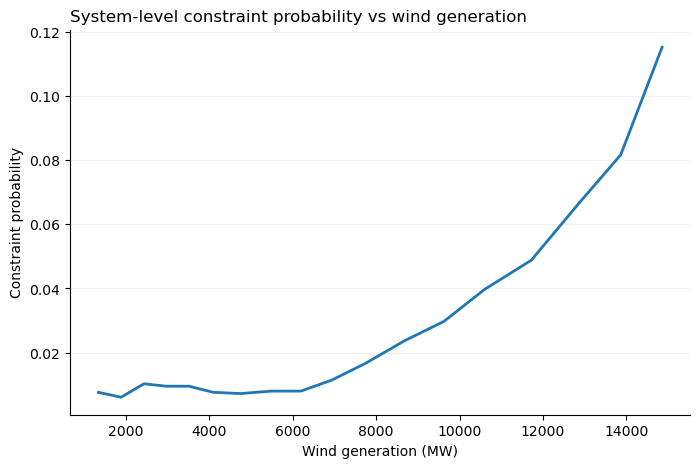

In [13]:
# =========================
# PLOT: WIND CURVE
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    wind_curve['wind_mid'],
    wind_curve['prob_smooth'],
    linewidth=2
)

# Labels
plt.xlabel("Wind generation (MW)")
plt.ylabel("Constraint probability")

# Title (left-aligned)
plt.title("System-level constraint probability vs wind generation", loc='left')

# Minimal styling
plt.grid(axis='y', alpha=0.15)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

Constraint probability increases non-linearly with wind generation
at the system level, with a clear acceleration at high output levels.

In [14]:
## Stratified Plot

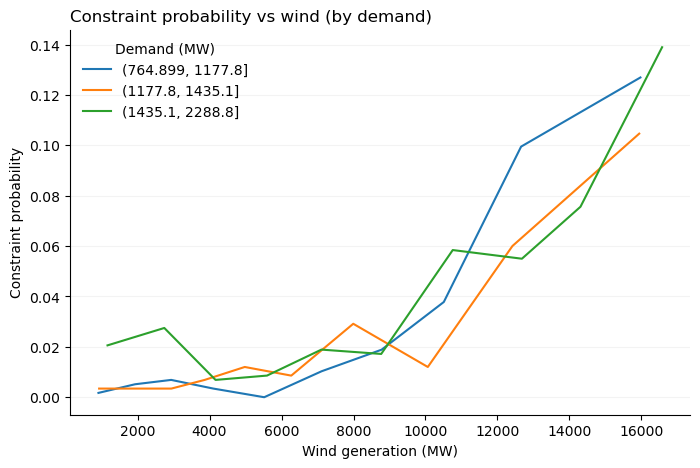

In [15]:
# =========================
# STRATIFIED CURVES
# =========================

df['demand_bucket'] = pd.qcut(df['sw_demand_mw'], 3)

plt.figure(figsize=(8,5))

for label, group in df.groupby('demand_bucket', observed=True):
    
    temp = group.copy()
    temp['wind_bucket'] = pd.qcut(temp['wind_mw'], 10, duplicates='drop')
    
    curve = (
        temp.groupby('wind_bucket', observed=True)['constraint_event']
        .mean()
        .reset_index()
    )
    
    curve['wind_mid'] = curve['wind_bucket'].apply(lambda x: x.mid)
    curve = curve.sort_values('wind_mid')
    # curve['prob_smooth'] = curve['constraint_event'].rolling(3, center=True).mean()
    
    plt.plot(
        curve['wind_mid'],
        curve['constraint_event'],
        linewidth=1.5,
        label=str(label)
    )

# =========================
# STYLE: STRATIFIED PLOT
# =========================

plt.xlabel("Wind generation (MW)")
plt.ylabel("Constraint probability")

plt.title("Constraint probability vs wind (by demand)", loc='left')

plt.legend(title="Demand (MW)", frameon=False)

plt.grid(axis='y', alpha=0.15)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

## Interpretation

Stratified wind curves show substantial overlap across demand regimes.
While demand contributes positively to constraint risk, wind remains
the dominant observable driver in system-level data.

Interaction effects are statistically significant but not cleanly
separable in aggregated data.

## Next step: regional analysis

This system-level result suggests that constraint risk is driven by wind.
However, this reflects aggregated behaviour across the network.

The next notebook introduces region-specific data for the South West,
revealing how local constraint dynamics can differ materially
from system-level patterns.